# OASIS INFOBYTE — Level 2, Task 1
## Predicting House Prices with Linear Regression

**Goal:** Build and evaluate a regression model, inspect the data, explain feature choices, and examine residuals and coefficients.

**Dataset note:** This notebook uses scikit-learn's California Housing dataset. It is a public housing dataset and avoids requiring a Kaggle login. It includes location (latitude/longitude), median house age, rooms, bedrooms, population, households, income, and median house value. `MedHouseVal` is the target, measured in units of $100,000.

Run the cells from top to bottom in Google Colab or Jupyter.


In [1]:
# 1. Import libraries
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

sns.set_theme()
RANDOM_STATE = 42


In [2]:
# 2. Load dataset
housing = fetch_california_housing(as_frame=True)
df = housing.frame.copy()
df = df.rename(columns={
    "MedInc": "median_income",
    "HouseAge": "house_age",
    "AveRooms": "average_rooms",
    "AveBedrms": "average_bedrooms",
    "Population": "population",
    "AveOccup": "average_occupancy",
    "Latitude": "latitude",
    "Longitude": "longitude",
    "MedHouseVal": "price"
})
df.head()


,median_income,house_age,average_rooms,average_bedrooms,population,average_occupancy,latitude,longitude,price
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [3]:
# 3. Basic structure and null check
print("Shape:", df.shape)
display(df.head())
display(df.info())
print("\\nMissing values per column:")
display(df.isnull().sum())
print("\\nDuplicate rows:", df.duplicated().sum())
display(df.describe().T)


Shape: (20640, 9)


,median_income,house_age,average_rooms,average_bedrooms,population,average_occupancy,latitude,longitude,price
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   median_income      20640 non-null  float64
 1   house_age          20640 non-null  float64
 2   average_rooms      20640 non-null  float64
 3   average_bedrooms   20640 non-null  float64
 4   population         20640 non-null  float64
 5   average_occupancy  20640 non-null  float64
 6   latitude           20640 non-null  float64
 7   longitude          20640 non-null  float64
 8   price              20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


None

\nMissing values per column:


,0
median_income,0
house_age,0
average_rooms,0
average_bedrooms,0
population,0
average_occupancy,0
latitude,0
longitude,0
price,0


\nDuplicate rows: 0


,count,mean,std,min,25%,50%,75%,max
median_income,20640.0,3.870671,1.899822,0.499900,2.563400,3.534800,4.743250,15.000100
house_age,20640.0,28.639486,12.585558,1.000000,18.000000,29.000000,37.000000,52.000000
average_rooms,20640.0,5.429000,2.474173,0.846154,4.440716,5.229129,6.052381,141.909091
average_bedrooms,20640.0,1.096675,0.473911,0.333333,1.006079,1.048780,1.099526,34.066667
population,20640.0,1425.476744,1132.462122,3.000000,787.000000,1166.000000,1725.000000,35682.000000
average_occupancy,20640.0,3.070655,10.386050,0.692308,2.429741,2.818116,3.282261,1243.333333
latitude,20640.0,35.631861,2.135952,32.540000,33.930000,34.260000,37.710000,41.950000
longitude,20640.0,-119.569704,2.003532,-124.350000,-121.800000,-118.490000,-118.010000,-114.310000
price,20640.0,2.068558,1.153956,0.149990,1.196000,1.797000,2.647250,5.000010


## Exploratory Data Analysis (EDA)

The target `price` is median house value. The input features include income, house age, room/bedroom counts, occupancy, population, and geographic coordinates.

**Feature selection discussion:** Median income is likely useful because neighbourhood income can relate to housing prices. Location (latitude and longitude) captures geographic differences. Room counts and house age may also help, while population and occupancy provide context about neighbourhood density. These are associations, not proof of causation.


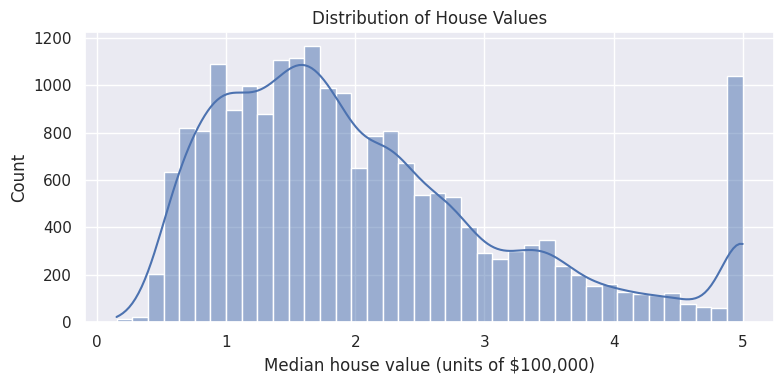

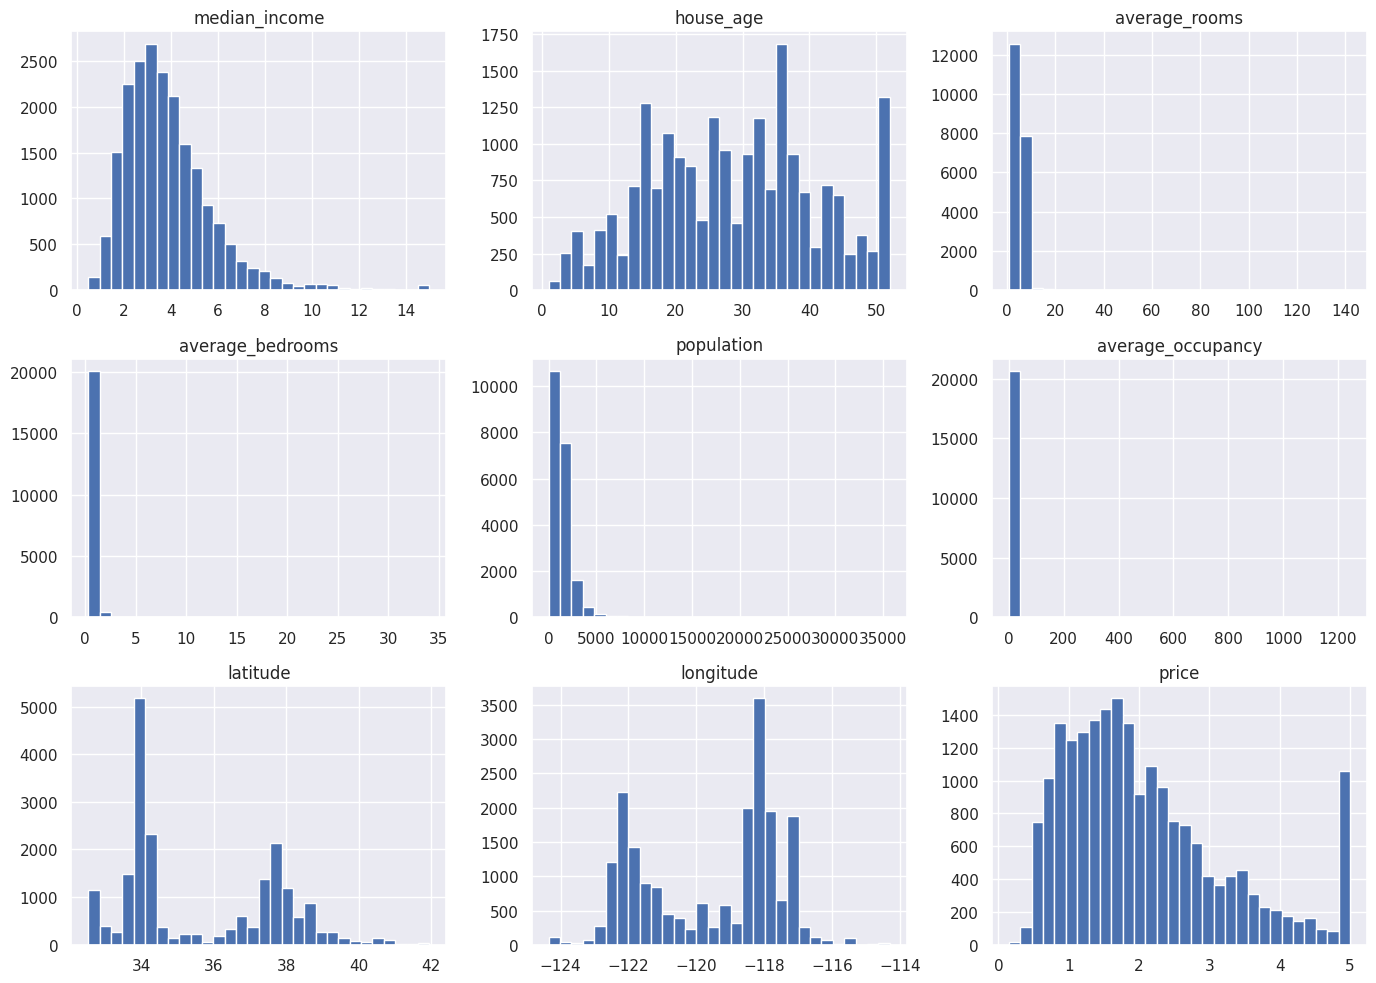

In [4]:
# 4. Target distribution and feature distributions
plt.figure(figsize=(8, 4))
sns.histplot(df["price"], bins=40, kde=True)
plt.title("Distribution of House Values")
plt.xlabel("Median house value (units of $100,000)")
plt.tight_layout()
plt.show()

df.hist(figsize=(14, 10), bins=30)
plt.tight_layout()
plt.show()


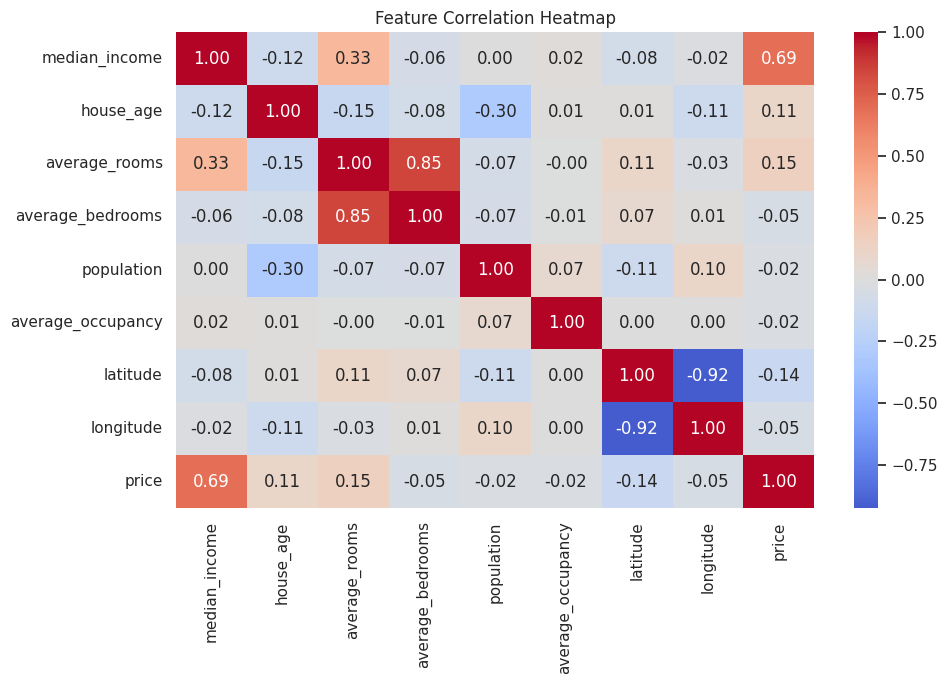

,price
price,1.000000
median_income,0.688075
average_rooms,0.151948
house_age,0.105623
average_occupancy,-0.023737
population,-0.024650
longitude,-0.045967
average_bedrooms,-0.046701
latitude,-0.144160


In [5]:
# 5. Correlation heatmap
plt.figure(figsize=(10, 7))
sns.heatmap(df.corr(numeric_only=True), annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Feature Correlation Heatmap")
plt.tight_layout()
plt.show()

display(df.corr(numeric_only=True)["price"].sort_values(ascending=False))


## Data cleaning and feature preparation

The original dataset has numeric features, so one-hot encoding is not needed for the original columns. To demonstrate categorical encoding as requested, we create a broad `location_zone` category from latitude and longitude and one-hot encode it. This is a simple illustrative grouping rather than an official geographic classification. The imputer also protects the pipeline if missing values are present.


In [6]:
# 6. Create a simple categorical location feature for encoding demonstration
df["location_zone"] = np.where(
    (df["latitude"] >= df["latitude"].median()) &
    (df["longitude"] >= df["longitude"].median()), "north_east",
    np.where(df["latitude"] >= df["latitude"].median(), "north_west",
             np.where(df["longitude"] >= df["longitude"].median(), "south_east", "south_west"))
)

X = df.drop(columns=["price"])
y = df["price"]

numeric_features = X.select_dtypes(include=np.number).columns.tolist()
categorical_features = ["location_zone"]

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])
categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])
preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features)
])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE
)
print("Training rows:", len(X_train), "| Test rows:", len(X_test))


Training rows: 16512 | Test rows: 4128


In [7]:
# 7. Train Linear Regression model
linear_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", LinearRegression())
])
linear_model.fit(X_train, y_train)
pred = linear_model.predict(X_test)

mse = mean_squared_error(y_test, pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, pred)
r2 = r2_score(y_test, pred)

print(f"MSE : {mse:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"MAE : {mae:.4f}")
print(f"R²  : {r2:.4f}")


MSE : 0.5411
RMSE: 0.7356
MAE : 0.5270
R²  : 0.5871


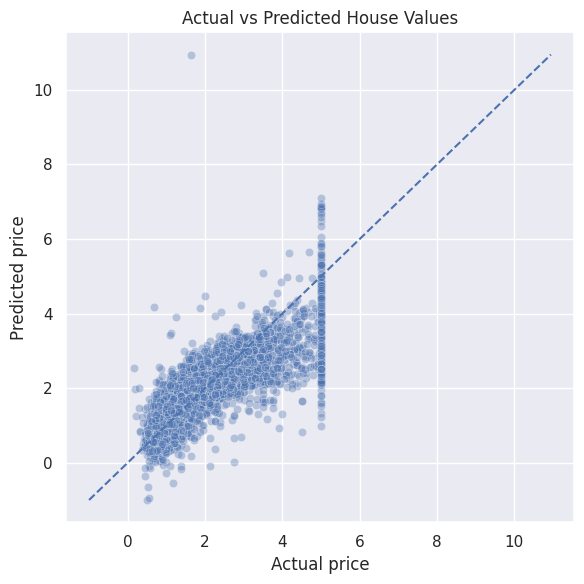

In [8]:
# 8. Actual vs predicted scatter plot
plt.figure(figsize=(6, 6))
sns.scatterplot(x=y_test, y=pred, alpha=0.35)
low = min(y_test.min(), pred.min())
high = max(y_test.max(), pred.max())
plt.plot([low, high], [low, high], linestyle="--")
plt.xlabel("Actual price")
plt.ylabel("Predicted price")
plt.title("Actual vs Predicted House Values")
plt.tight_layout()
plt.show()


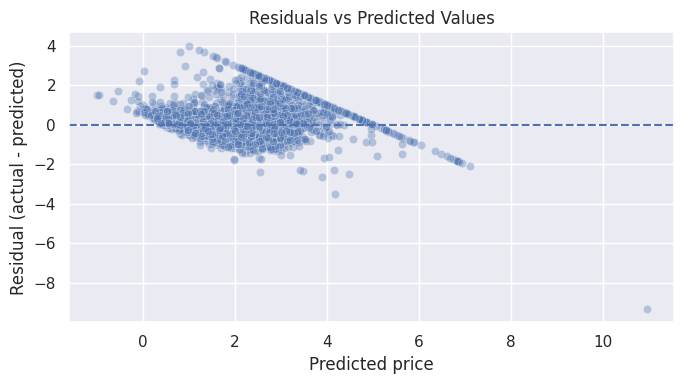

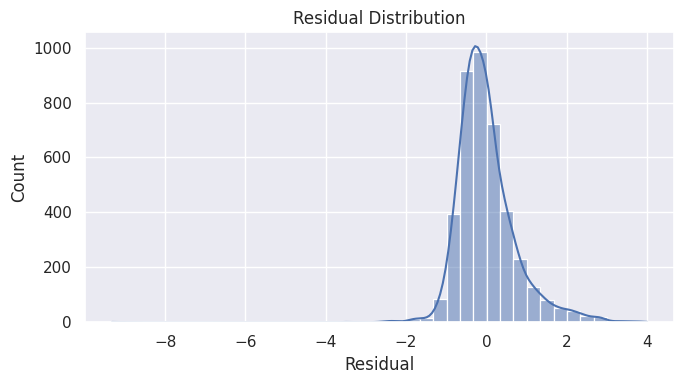

Residual mean: 0.0039


In [9]:
# 9. Residual analysis
residuals = y_test - pred
plt.figure(figsize=(7, 4))
sns.scatterplot(x=pred, y=residuals, alpha=0.35)
plt.axhline(0, linestyle="--")
plt.xlabel("Predicted price")
plt.ylabel("Residual (actual - predicted)")
plt.title("Residuals vs Predicted Values")
plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 4))
sns.histplot(residuals, bins=40, kde=True)
plt.title("Residual Distribution")
plt.xlabel("Residual")
plt.tight_layout()
plt.show()
print("Residual mean:", round(float(residuals.mean()), 4))


,feature,coefficient,absolute_coefficient
7,num__longitude,-1.038927,1.038927
0,num__median_income,0.815337,0.815337
6,num__latitude,-0.806900,0.806900
9,cat__location_zone_north_west,-0.367590,0.367590
3,num__average_bedrooms,0.289988,0.289988
2,num__average_rooms,-0.231801,0.231801
10,cat__location_zone_south_east,0.208845,0.208845
11,cat__location_zone_south_west,0.207618,0.207618
1,num__house_age,0.095151,0.095151
8,cat__location_zone_north_east,-0.048874,0.048874


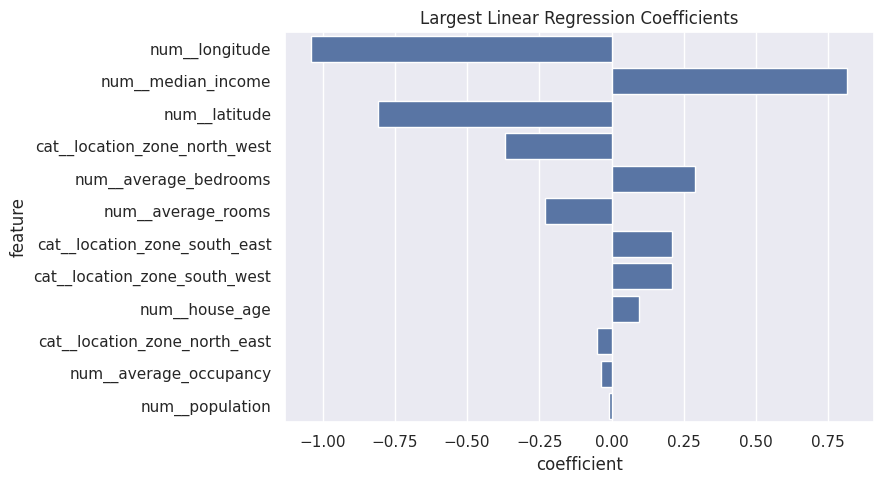

In [10]:
# 10. Coefficient / feature impact inspection
feature_names = linear_model.named_steps["preprocessor"].get_feature_names_out()
coefficients = linear_model.named_steps["model"].coef_
coef_df = pd.DataFrame({"feature": feature_names, "coefficient": coefficients})
coef_df["absolute_coefficient"] = coef_df["coefficient"].abs()
display(coef_df.sort_values("absolute_coefficient", ascending=False).head(15))

plt.figure(figsize=(9, 5))
top = coef_df.sort_values("absolute_coefficient", ascending=False).head(12)
sns.barplot(data=top, x="coefficient", y="feature")
plt.title("Largest Linear Regression Coefficients")
plt.tight_layout()
plt.show()


### How to interpret coefficients
Because numeric features are standardized, their coefficients describe the estimated change in the target for a one-standard-deviation increase in that feature, holding other inputs constant. Positive coefficients indicate a positive model association; negative coefficients indicate a negative association. One-hot encoded zone coefficients are relative to the dropped/reference category. Coefficients do not establish causality.

### Residual interpretation
A good residual plot has points scattered around zero without a strong curve or funnel. Visible patterns can indicate non-linearity, unequal error variance, or missing predictors. House prices can have a ceiling in this dataset, so errors may not be perfectly random.


In [11]:
# 11. Bonus: compare Linear Regression, Ridge and Lasso
models = {
    "Linear Regression": LinearRegression(),
    "Ridge": Ridge(alpha=1.0),
    "Lasso": Lasso(alpha=0.001, max_iter=10000)
}
results = []
for name, estimator in models.items():
    pipe = Pipeline(steps=[("preprocessor", preprocessor), ("model", estimator)])
    pipe.fit(X_train, y_train)
    p = pipe.predict(X_test)
    results.append({
        "Model": name,
        "MSE": mean_squared_error(y_test, p),
        "RMSE": np.sqrt(mean_squared_error(y_test, p)),
        "MAE": mean_absolute_error(y_test, p),
        "R2": r2_score(y_test, p)
    })
results_df = pd.DataFrame(results).sort_values("RMSE")
display(results_df)


,Model,MSE,RMSE,MAE,R2
2,Lasso,0.539812,0.734719,0.526552,0.588058
1,Ridge,0.541079,0.735580,0.526934,0.587092
0,Linear Regression,0.541109,0.735601,0.526950,0.587069


## Conclusion (complete after running)

Fill in the actual metric values printed above in your report. State which model had the lowest RMSE, whether the actual-vs-predicted points were close to the diagonal, and whether the residual plot showed a pattern. Do not claim a model is accurate without referring to these results.

**Limitations:** This dataset represents California census-block groups and is not a current listing-level valuation tool. The data are observational, and results may not generalize to other regions.
